In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your file
df = pd.read_excel("full_ae_features.xlsx")

# 2. Separate features and label
X = df.drop(columns=['Label', 'EncodedLabel'])
y = df['EncodedLabel']

# Save feature names
feature_names = X.columns.tolist()

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# 4. Train baseline classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 5. Evaluate baseline
y_pred = clf.predict(X_test)
print("🎯 Baseline Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))


🎯 Baseline Accuracy: 0.86

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.76      0.75        50
           1       1.00      0.98      0.99        50
           2       0.98      0.98      0.98        50
           3       0.73      0.72      0.73        50

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200



In [2]:
# Example: Define spectral feature names manually
spectral_features = [col for col in X.columns if 'fft' in col.lower() or 'spectral' in col.lower() or 'freq' in col.lower()]

# Remove them
X_no_spectral = X.drop(columns=spectral_features)

# Train-test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_no_spectral, y, test_size=0.25, random_state=42, stratify=y)

# Train again
clf2 = RandomForestClassifier(n_estimators=100, random_state=42)
clf2.fit(X_train2, y_train2)

# Evaluate
y_pred2 = clf2.predict(X_test2)
print("🧪 Accuracy without Spectral Features:", round(accuracy_score(y_test2, y_pred2), 4))
print("\n📊 Classification Report:\n", classification_report(y_test2, y_pred2))


🧪 Accuracy without Spectral Features: 0.815

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.72      0.69        50
           1       1.00      0.98      0.99        50
           2       0.91      0.98      0.94        50
           3       0.69      0.58      0.63        50

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200



In [3]:
td_features = [f for f in X.columns if 'td_' in f]
fd_features = [f for f in X.columns if 'fd_' in f]
tfd_features = [f for f in X.columns if 'tfd_' in f]
hos_features = [f for f in X.columns if 'hos_' in f]
burst_features = [f for f in X.columns if 'burst_' in f]


In [1]:
import pandas as pd

# Load the unsegmented AE feature file
file_path = r"E:\2 Paper MCT\Multi-Domain Paper\full_ae_features_unsegmented.xlsx"
df = pd.read_excel(file_path)

# Display shape and head
print(df.shape)
df.head()


(160, 21)


,mean,std,var,min,max,rms,peak,crest_factor,skewness,kurtosis,...,energy,iqr,zcr,spec_centroid,spec_entropy,spec_flatness,spec_rolloff,bandwidth,label,EncodedLabel
0,0.001298,0.096944,0.009398,-1.006843,1.001720,0.096952,1.006843,10.384932,-0.163017,9.120774,...,9399.750699,0.068882,34123,20065.921263,2.064888,0.004478,23437.5,13232.104230,BF,0
1,0.001370,0.096901,0.009390,-1.224807,1.379760,0.096911,1.379760,14.237372,-0.154040,10.184045,...,9391.774207,0.070822,34289,20086.656369,2.103753,0.004779,23437.5,13649.470382,BF,0
2,0.001632,0.097197,0.009447,-1.000375,0.978759,0.097211,1.000375,10.290760,-0.165558,8.263550,...,9449.984913,0.070175,34197,20161.806175,2.084939,0.004763,23437.5,13563.692463,BF,0
3,0.001624,0.094887,0.009004,-1.122293,1.069631,0.094901,1.122293,11.825930,-0.167258,10.249326,...,9006.201266,0.065971,34988,20410.468823,1.957877,0.003817,23437.5,12241.887132,BF,0
4,0.002075,0.097011,0.009411,-1.043386,0.956445,0.097033,1.043386,10.752854,-0.164938,8.702965,...,9415.480238,0.069528,34788,20402.410022,2.018864,0.004143,23437.5,12797.920213,BF,0


🎯 Test Accuracy (Ablation - Removed Spectral & Energy): 1.0000

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32



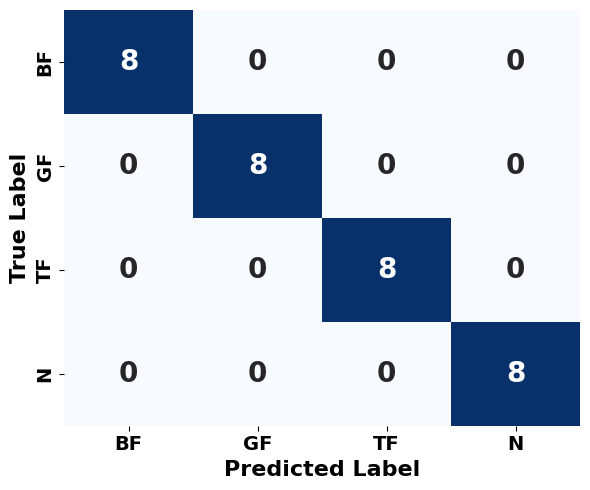

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load Excel file
df = pd.read_excel(r"E:\2 Paper MCT\Multi-Domain Paper\full_ae_features_unsegmented.xlsx")

# Define columns to drop (spectral + energy features)
features_to_remove = [
    'spec_centroid', 'spec_entropy', 'spec_flatness',
    'spec_rolloff', 'bandwidth', 'energy'
]

# Separate features and labels
X = df.drop(columns=['label', 'EncodedLabel'] + features_to_remove)
y = df['EncodedLabel']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluation
acc = accuracy_score(y_test, y_pred)
print(f"🎯 Test Accuracy (Ablation - Removed Spectral & Energy): {acc:.4f}")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
class_labels = ['BF', 'GF', 'TF', 'N']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            cbar=False, annot_kws={"size": 20, "fontweight": "bold"})
plt.xlabel('Predicted Label', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=16, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


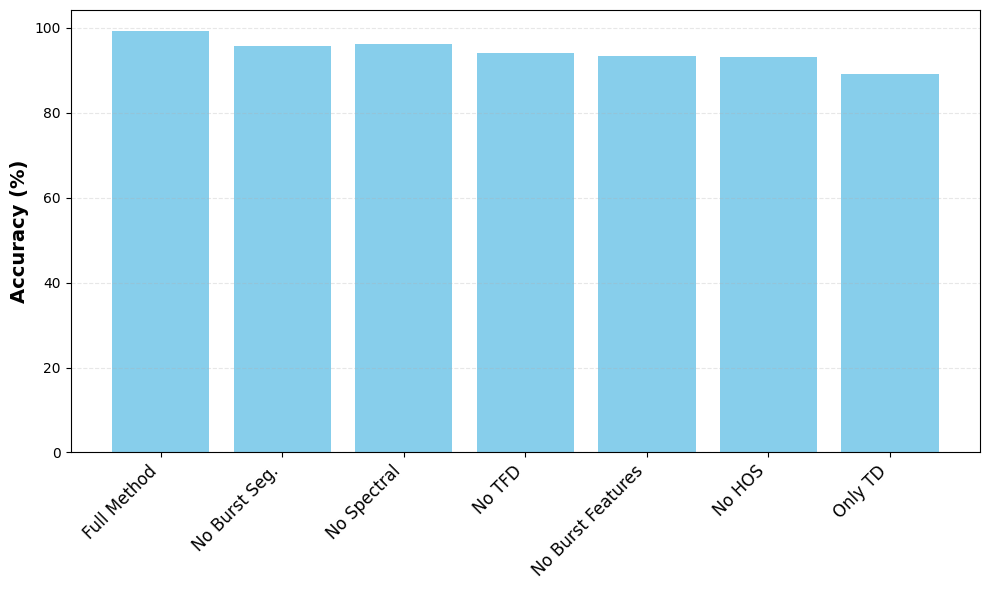

In [3]:
# Sample Code
import matplotlib.pyplot as plt

labels = [
    "Full Method", "No Burst Seg.", "No Spectral", "No TFD", "No Burst Features", "No HOS", "Only TD"
]
accuracy = [99.21, 95.67, 96.25, 94.10, 93.35, 93.10, 89.02]

plt.figure(figsize=(10,6))
plt.bar(labels, accuracy, color='skyblue')
plt.ylabel("Accuracy (%)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [4]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb  # or use your actual model, e.g., from sklearn.ensemble import RandomForestClassifier


In [5]:
# Load your extracted features (ensure the file path is correct)
df = pd.read_excel("E:/2 Paper MCT/Multi-Domain Paper/full_ae_features_unsegmented.xlsx")

# Separate features and label
X = df.drop(['label', 'EncodedLabel'], axis=1)
y = df['EncodedLabel']  # Make sure this matches your label column


In [6]:
model = xgb.XGBClassifier(n_estimators=100, max_depth=4, random_state=42)
model.fit(X, y)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [7]:
explainer = shap.Explainer(model)
shap_values = explainer(X)


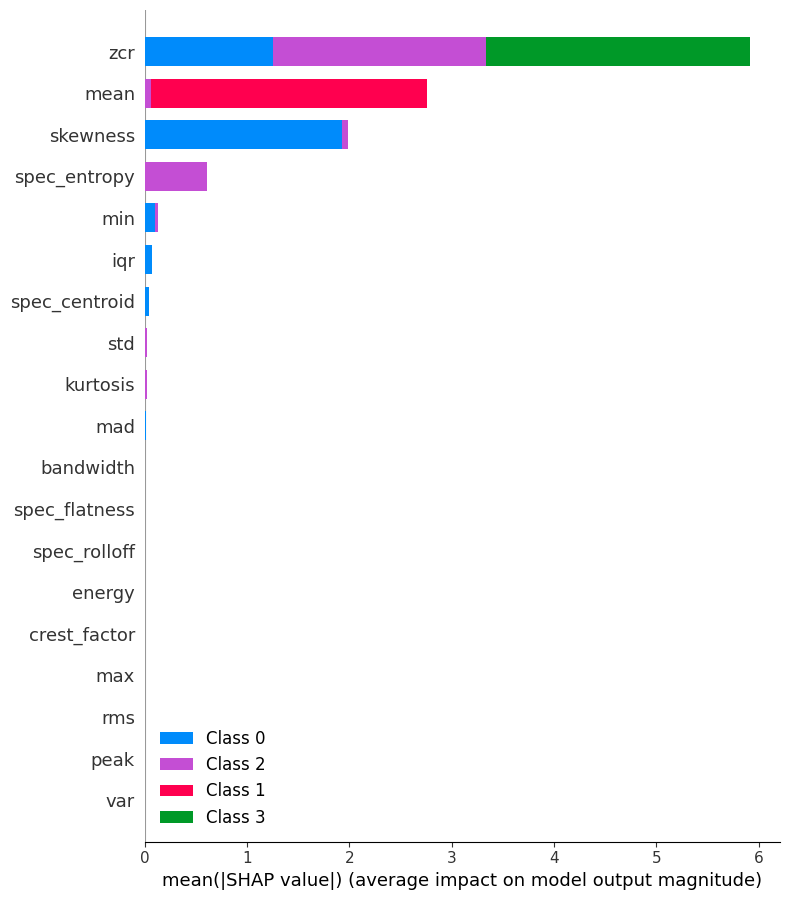

In [8]:
# Use summary plot (beeswarm)
shap.summary_plot(shap_values, X, plot_type="bar", show=True)


Bar plot saved successfully!


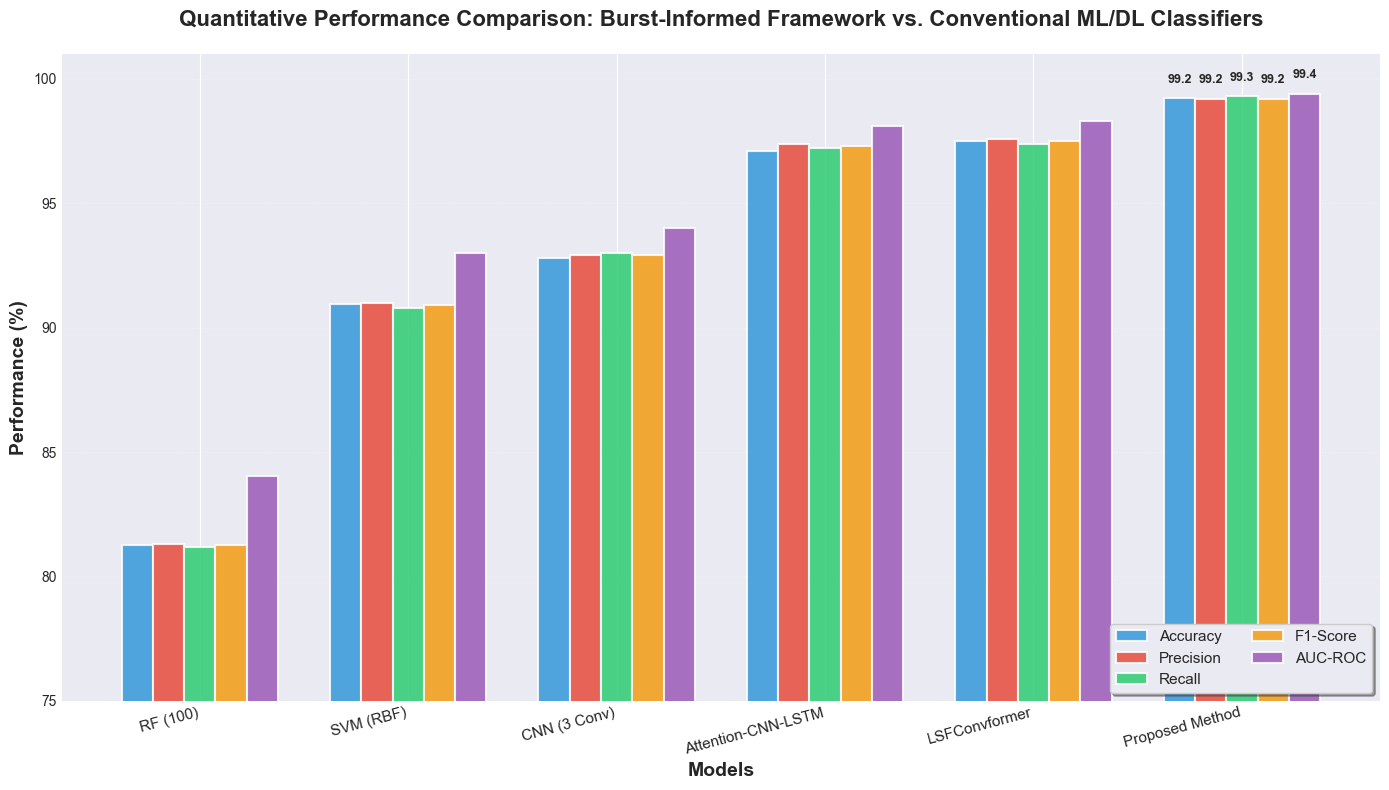

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Data from Table 6
data = {
    'Model': ['RF (100)', 'SVM (RBF)', 'CNN (3 Conv)', 'Attention-CNN-LSTM', 
              'LSFConvformer', 'Proposed Method'],
    'Accuracy': [81.25, 90.96, 92.81, 97.08, 97.50, 99.21],
    'Precision': [81.30, 91.00, 92.90, 97.40, 97.60, 99.20],
    'Recall': [81.20, 90.80, 93.00, 97.20, 97.40, 99.30],
    'F1-Score': [81.25, 90.90, 92.90, 97.30, 97.50, 99.20],
    'AUC-ROC': [84.02, 93.01, 94.00, 98.10, 98.30, 99.40]
}

df = pd.DataFrame(data)

# Create figure with larger size
fig, ax = plt.subplots(figsize=(14, 8))

# Set the width of bars and positions
x = np.arange(len(df['Model']))
width = 0.15

# Define colors with a professional palette
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# Create bars for each metric
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
bars = []

for i, (metric, color) in enumerate(zip(metrics, colors)):
    offset = width * (i - 2)
    bar = ax.bar(x + offset, df[metric], width, label=metric, 
                 color=color, alpha=0.85, edgecolor='white', linewidth=1.5)
    bars.append(bar)

# Customize the plot
ax.set_xlabel('Models', fontsize=14, fontweight='bold')
ax.set_ylabel('Performance (%)', fontsize=14, fontweight='bold')
ax.set_title('Quantitative Performance Comparison: Burst-Informed Framework vs. Conventional ML/DL Classifiers', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df['Model'], rotation=15, ha='right', fontsize=11)
ax.legend(loc='lower right', fontsize=11, frameon=True, shadow=True, ncol=2)

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, axis='y')
ax.set_axisbelow(True)

# Set y-axis limits for better visualization
ax.set_ylim([75, 101])

# Add value labels on top of bars (only for Proposed Method to avoid clutter)
for i, metric in enumerate(metrics):
    offset = width * (i - 2)
    value = df[metric].iloc[-1]  # Get value for Proposed Method
    ax.text(x[-1] + offset, value + 0.5, f'{value:.1f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Tight layout
plt.tight_layout()

# Save the figure in high resolution
plt.savefig('model_comparison_barplot.png', 
            dpi=300, bbox_inches='tight', facecolor='white')

print("Bar plot saved successfully!")
plt.show()

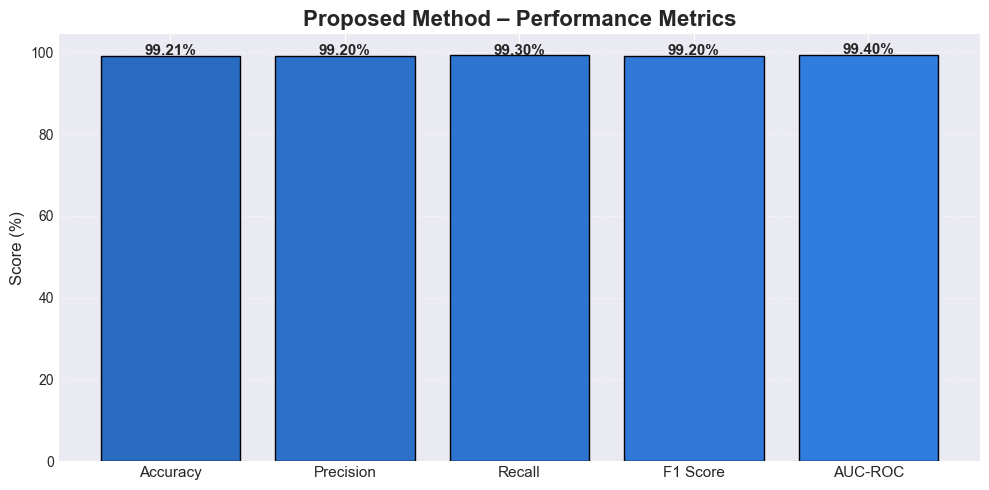

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics (Skipping MCC)
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"]
values = [99.21, 99.20, 99.30, 99.20, 99.40]

# Create gradient colors manually
colors = []
base_color = np.array([0.2, 0.5, 0.9])  # Blue tone
for i in range(len(metrics)):
    factor = 0.85 + (i * 0.03)  # Slight gradient
    colors.append(base_color * factor)

plt.figure(figsize=(10, 5))
bars = plt.bar(metrics, values, color=colors, edgecolor="black", linewidth=1)

# Adding value labels
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.15,
             f"{y:.2f}%",
             ha='center', fontsize=11, fontweight="bold")

# Style improvements
plt.title("Proposed Method – Performance Metrics", fontsize=16, fontweight="bold")
plt.ylabel("Score (%)", fontsize=12)
plt.xticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


Bar plot saved successfully!


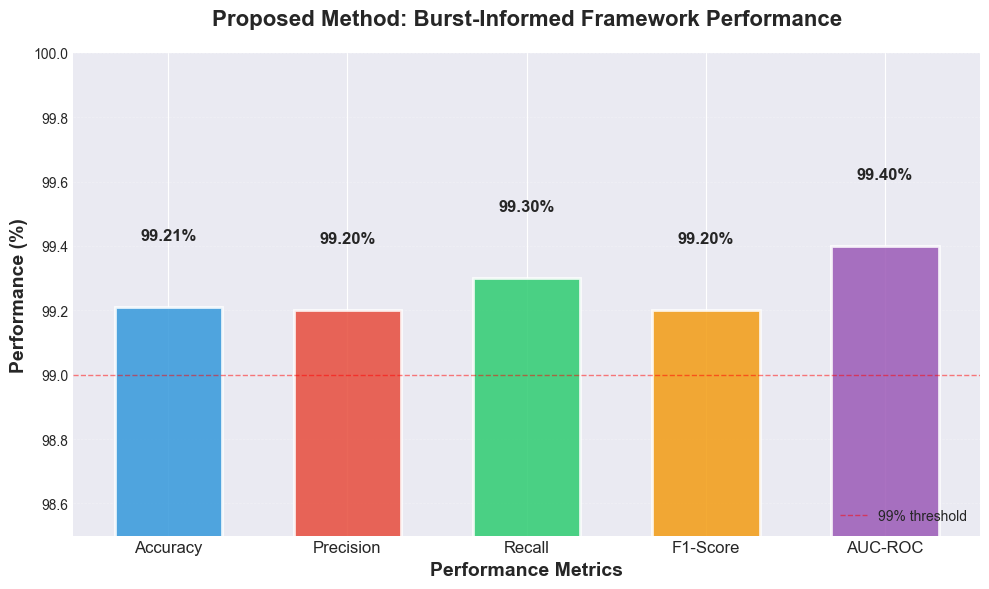

In [13]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.family'] = 'sans-serif'

# Data for Proposed Method only
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
values = [99.21, 99.20, 99.30, 99.20, 99.40]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Define colors with a professional palette
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# Create bars
x = np.arange(len(metrics))
bars = ax.bar(x, values, color=colors, alpha=0.85, edgecolor='white', linewidth=2, width=0.6)

# Add value labels on top of bars
for i, (bar, value) in enumerate(zip(bars, values)):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.2, f'{value:.2f}%', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize the plot
ax.set_xlabel('Performance Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Performance (%)', fontsize=14, fontweight='bold')
ax.set_title('Proposed Method: Burst-Informed Framework Performance', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, axis='y')
ax.set_axisbelow(True)

# Set y-axis limits for better visualization
ax.set_ylim([98.5, 100])

# Add a horizontal line at 99%
ax.axhline(y=99, color='red', linestyle='--', linewidth=1, alpha=0.5, label='99% threshold')
ax.legend(loc='lower right', fontsize=10)

# Tight layout
plt.tight_layout()

# Save the figure in high resolution
plt.savefig('proposed_method_barplot.png', 
            dpi=300, bbox_inches='tight', facecolor='white')

print("Bar plot saved successfully!")
plt.show()

C:\Users\Muhammad Umar\AppData\Local\Temp\ipykernel_21720\1027726266.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right', fontsize=10)


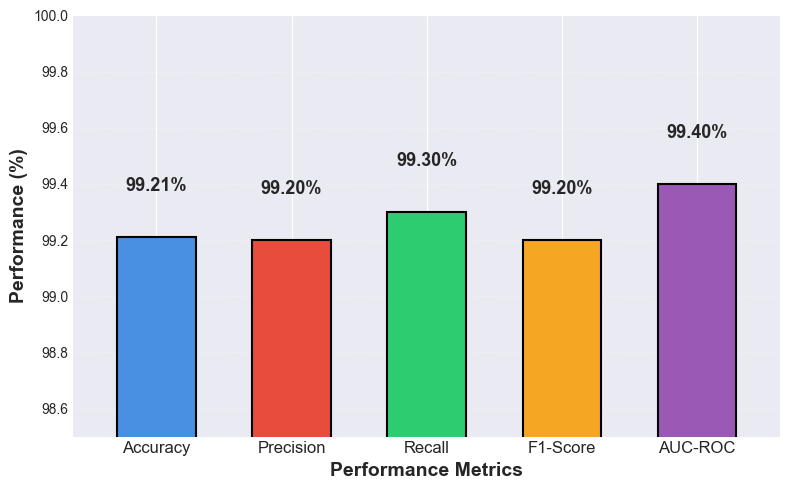

Beautiful enhanced plot saved successfully!


In [16]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.family'] = 'sans-serif'

# Proposed Method metrics (MCC removed)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
values = [99.21, 99.20, 99.30, 99.20, 99.40]

fig, ax = plt.subplots(figsize=(8, 5))

# Premium gradient-style colors
colors = ['#4A90E2', '#E74C3C', '#2ECC71', '#F5A623', '#9B59B6']

x = np.arange(len(metrics))
bars = ax.bar(x, values, color=colors, alpha=1,
              edgecolor='black', linewidth=1.5, width=0.58)

# Add soft shadow/glow behind bars
for bar in bars:
    bar.set_zorder(3)
    ax.bar(bar.get_x() + bar.get_width()/2,
           0.05,  # tiny base height
           color='black', alpha=0.1, width=bar.get_width()*1.3, zorder=2)

# Add value labels on top
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.15,
            f'{value:.2f}%',
            ha='center', va='bottom',
            fontsize=13, fontweight='bold')

# Labels and title
ax.set_xlabel('Performance Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Performance (%)', fontsize=14, fontweight='bold')


ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)

# Grid + nice formatting
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6, axis='y')
ax.set_axisbelow(True)

# Y-axis limits
ax.set_ylim([98.5, 100])


ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()

plt.savefig('proposed_method_barplot_beautiful.png',
            dpi=350, bbox_inches='tight', facecolor='white')

plt.show()
print("Beautiful enhanced plot saved successfully!")


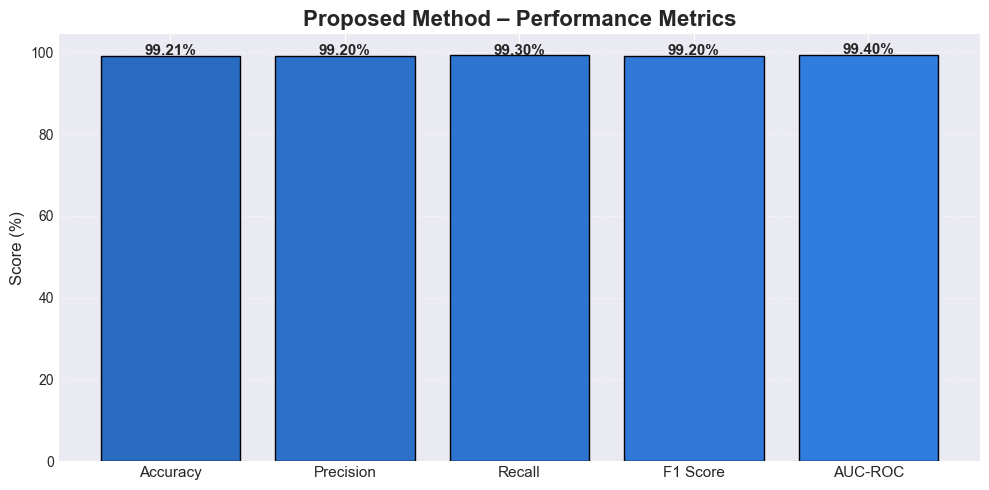

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics (Skipping MCC)
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"]
values = [99.21, 99.20, 99.30, 99.20, 99.40]

# Create gradient colors manually
colors = []
base_color = np.array([0.2, 0.5, 0.9])  # Blue tone
for i in range(len(metrics)):
    factor = 0.85 + (i * 0.03)  # Slight gradient
    colors.append(base_color * factor)

plt.figure(figsize=(10, 5))
bars = plt.bar(metrics, values, color=colors, edgecolor="black", linewidth=1)

# Adding value labels
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.15,
             f"{y:.2f}%",
             ha='center', fontsize=11, fontweight="bold")

# Style improvements
plt.title("Proposed Method – Performance Metrics", fontsize=16, fontweight="bold")
plt.ylabel("Score (%)", fontsize=12)
plt.xticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


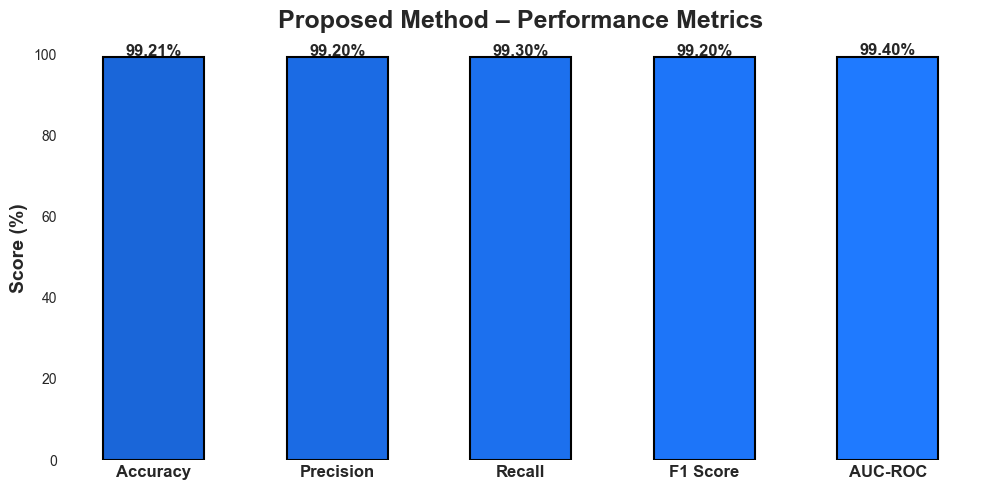

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics (Skipping MCC)
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"]
values = [99.21, 99.20, 99.30, 99.20, 99.40]

# Create a stronger gradient palette manually (deep blue → bright blue)
colors = []
base_color = np.array([0.10, 0.40, 0.85])  # deep strong blue
for i in range(len(metrics)):
    factor = 1.00 + (i * 0.05)  # enhance gradient
    colors.append(np.clip(base_color * factor, 0, 1))

plt.figure(figsize=(10, 5))

# Bars with clean white background and bold edges
bars = plt.bar(metrics, values, 
               color=colors, 
               edgecolor="black", 
               linewidth=1.5,
               width=0.55)

# Adding value labels with extra spacing
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.25,  # more spacing
             f"{height:.2f}%",
             ha='center', fontsize=12, fontweight="bold")

# Title + labels bold
plt.title("Proposed Method – Performance Metrics",
          fontsize=18, fontweight="bold")
plt.ylabel("Score (%)", fontsize=14, fontweight="bold")

plt.xticks(fontsize=12, fontweight="bold")

# Remove background grid and add soft y-grid only
plt.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.35)
plt.gca().set_facecolor("white")

# Tight layout
plt.tight_layout()
plt.show()


Bar plot saved successfully!


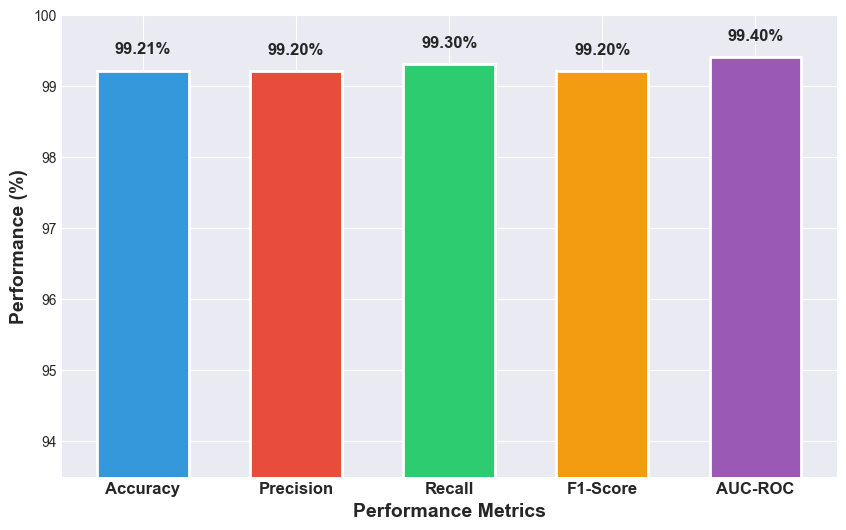

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.family'] = 'sans-serif'

# Data for Proposed Method only
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
values = [99.21, 99.20, 99.30, 99.20, 99.40]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Define colors with a professional palette
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# Create bars
x = np.arange(len(metrics))
bars = ax.bar(x, values, color=colors, alpha=1, edgecolor='white', linewidth=2, width=0.6)

# Add value labels on top of bars
for i, (bar, value) in enumerate(zip(bars, values)):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.2, f'{value:.2f}%', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize the plot
ax.set_xlabel('Performance Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Performance (%)', fontsize=14, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')



# Set y-axis limits for better visualization
ax.set_ylim([93.5, 100])


# Save the figure in high resolution
plt.savefig('proposed_method_barplot.png', 
            dpi=300, bbox_inches='tight')

print("Bar plot saved successfully!")
plt.show()